# Microstructure Features

**Chapter 8: Feature Engineering**
**Section Reference**: 8.2 - Price-Derived Features (Microstructure)
**Docker image**: `ml4t`

## Purpose

Microstructure features capture market dynamics invisible in daily OHLCV data.
They proxy for **liquidity**, **information flow**, and **execution quality**.

## Learning Objectives

1. Compute trade-based liquidity features (Kyle λ, Amihud, Roll spread)
2. Understand order flow imbalance and its predictive content
3. Distinguish between **flow features** and **state features** (critical!)
4. Know which features are alpha vs feasibility/cost inputs

## Feature Categories

| Category | Features | Data Required |
|----------|----------|---------------|
| **Liquidity** | Kyle λ, Amihud, Roll | OHLCV bars |
| **Order Flow** | OFI, trade intensity | Trade data |
| **Book State** | Spread, depth | LOB snapshots |

## Data Policy

Uses **real NASDAQ ITCH data**. The notebook raises a clear error when ITCH
is missing rather than substituting a synthetic toy panel.

In [1]:
"""Microstructure Features - compute trade-based liquidity and order flow features from tick data."""

from __future__ import annotations

import warnings
from datetime import time

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.reproducibility import set_global_seeds

# Importing utils.style registers and activates the ML4T Plotly template (house
# palette, fonts, white plot background) repo-wide; without it these figures fall
# back to the default Plotly template (blue-tinted background, matplotlib colorway).
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Data Loading with Availability Check

Microstructure analysis requires high-frequency data. The loader raises
a clear error if ITCH is missing - no silent fallback to synthetic data.

In [4]:
# Load real ITCH trade data - the notebook fails loudly if the data is
# missing rather than silently substituting a synthetic toy panel.

from data import load_nasdaq_itch

sample = load_nasdaq_itch(message_types=["P"], symbols=["AAPL"])
if len(sample) < 100:
    raise RuntimeError(
        f"Expected NASDAQ ITCH trade data with >=100 rows for AAPL; got {len(sample)}. "
        "Ensure ML4T_DATA_PATH is set and the ITCH dataset is downloaded."
    )
print(f"ITCH data available: {len(sample):,} trade messages loaded")

ITCH data available: 15,114 trade messages loaded


In [5]:
trades = load_nasdaq_itch(message_types=["P"], symbols=["AAPL", "MSFT", "TSLA"])

# Convert price from 10,000ths to dollars
trades = trades.with_columns((pl.col("price") / 10000.0).alias("price"))

# Filter to regular trading hours
trades = trades.filter(
    (pl.col("timestamp").dt.time() >= time(9, 30)) & (pl.col("timestamp").dt.time() < time(16, 0))
).sort(["stock", "timestamp"])

print(f"Loaded {len(trades):,} trades across {trades['stock'].n_unique()} stocks")

Loaded 88,572 trades across 3 stocks


## 2. Aggregate to Bars

Trade-based features work on aggregated bars (not tick-by-tick).
Common intervals: 1m, 5m, 15m for intraday; daily for cross-sectional.

In [6]:
from ml4t.engineer.features.microstructure import effective_tick_rule


def aggregate_to_bars(
    trades: pl.DataFrame,
    interval: str = "5m",
    stock_col: str = "stock",
    price_col: str = "price",
    volume_col: str = "shares",
) -> pl.DataFrame:
    """Aggregate trades to OHLCV bars with a trade-level buy/sell volume split.

    Order flow imbalance is a *flow* feature: it must be built from the sign of
    individual trades and then aggregated. We classify every trade with the tick
    rule (buyer- vs seller-initiated) BEFORE aggregating, so each bar carries a
    genuine ``buy_volume``/``sell_volume`` split. Classifying the bar *close*
    instead would only recover the sign of the bar's own return, collapsing OFI
    to +/-1 rather than measuring imbalance.
    """
    classified = trades.sort([stock_col, "timestamp"]).with_columns(
        effective_tick_rule(price_col).over(stock_col).alias("trade_sign")
    )
    bars = (
        classified.group_by_dynamic("timestamp", every=interval, by=stock_col)
        .agg(
            [
                pl.col(price_col).first().alias("open"),
                pl.col(price_col).max().alias("high"),
                pl.col(price_col).min().alias("low"),
                pl.col(price_col).last().alias("close"),
                pl.col(volume_col).sum().alias("volume"),
                pl.len().alias("trade_count"),
                pl.col(volume_col).filter(pl.col("trade_sign") > 0).sum().alias("buy_volume"),
                pl.col(volume_col).filter(pl.col("trade_sign") < 0).sum().alias("sell_volume"),
            ]
        )
        .sort([stock_col, "timestamp"])
    )

    # Add returns, dollar volume, and the genuine per-bar OFI. Cast the summed
    # share volumes to a signed dtype before subtracting: ``shares`` is unsigned
    # (UInt32), so buy - sell would silently underflow on net-selling bars.
    return bars.with_columns(
        [
            (pl.col("close") / pl.col("close").shift(1).over(stock_col) - 1).alias("returns"),
            (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
            pl.when((pl.col("buy_volume") + pl.col("sell_volume")) > 0)
            .then(
                (pl.col("buy_volume").cast(pl.Int64) - pl.col("sell_volume").cast(pl.Int64))
                / (pl.col("buy_volume") + pl.col("sell_volume"))
            )
            .otherwise(0.0)
            .alias("ofi"),
        ]
    )


# Create 5-minute bars
bars = aggregate_to_bars(trades, interval="5m")
print(f"Aggregated to {len(bars):,} bars")
print(f"Columns: {bars.columns}")

# Focus on one stock for visualization
FOCUS_STOCK = "AAPL"
focus_bars = bars.filter(pl.col("stock") == FOCUS_STOCK).drop_nulls(["returns"])
print(f"\n{FOCUS_STOCK}: {len(focus_bars):,} bars")

Aggregated to 234 bars
Columns: ['stock', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'buy_volume', 'sell_volume', 'returns', 'dollar_volume', 'ofi']

AAPL: 77 bars


## 3. Trade-Based Liquidity Features

These features require only OHLCV bars (widely available).
They proxy for market liquidity and trading costs.

| Feature | Formula | Interpretation |
|---------|---------|----------------|
| Kyle λ | Cov(ΔP, V) / Var(V) | Price impact per unit volume |
| Amihud | \|r\| / DollarVol | Illiquidity ratio |
| Roll Spread | 2√(-Cov(ΔP_t, ΔP_{t-1})) | Implied bid-ask spread |

In [7]:
from ml4t.engineer.features.microstructure import (
    amihud_illiquidity,
    kyle_lambda,
    roll_spread_estimator,
    trade_intensity,
)

# Compute the trade-based liquidity features. ``ofi`` already lives on the bars
# (built from the trade-level buy/sell split in aggregate_to_bars), so it is not
# recomputed here.
PERIOD = 20

features_df = focus_bars.with_columns(
    [
        # Liquidity measures
        kyle_lambda("returns", "volume", period=PERIOD).alias("kyle_lambda"),
        amihud_illiquidity("returns", "volume", "close", period=PERIOD).alias("amihud"),
        roll_spread_estimator("close", period=PERIOD).alias("roll_spread"),
        trade_intensity("volume", period=PERIOD).alias("trade_intensity"),
    ]
)

features_df = features_df.drop_nulls(["kyle_lambda", "amihud"])

print("Trade-based features computed:")
features_df.select(["timestamp", "close", "kyle_lambda", "amihud", "roll_spread", "ofi"]).tail(10)

Trade-based features computed:


timestamp,close,kyle_lambda,amihud,roll_spread,ofi
datetime[ns],f64,f64,f64,f64,f64
2020-01-30 15:10:00,321.08,0.001004,0.000565,0.316581,-0.082348
2020-01-30 15:15:00,321.71,0.001066,0.000565,0.235676,0.421245
2020-01-30 15:20:00,322.23,0.001143,0.000586,0.064782,0.447878
2020-01-30 15:25:00,321.77,0.001174,0.000557,0.207022,-0.131579
2020-01-30 15:30:00,322.05,0.001106,0.000494,0.214769,0.068913
2020-01-30 15:35:00,322.355,0.00113,0.000487,0.197683,0.054177
2020-01-30 15:40:00,322.72,0.001154,0.000492,0.174818,0.023755
2020-01-30 15:45:00,323.085,0.001169,0.000484,0.156797,0.162584
2020-01-30 15:50:00,323.38,0.001077,0.000409,0.222852,0.046178


**Interpretation**: Kyle lambda measures price impact per unit volume -- higher
values mean the market is less liquid. Amihud illiquidity captures the same
concept via |return|/dollar-volume. Despite both proxying for illiquidity,
their correlation can be weak or negative with small samples because
they emphasize different aspects: Kyle lambda uses return-volume covariance
(directional impact), while Amihud uses absolute return per dollar traded.
Cross-sectional agreement improves with longer samples and more stocks.

### 3.1 Kyle Lambda (Price Impact)

High Kyle λ means prices move significantly per unit of volume - the market
is **illiquid** and trades have high impact.

$$\lambda = \frac{\text{Cov}(\Delta P, V)}{\text{Var}(V)}$$

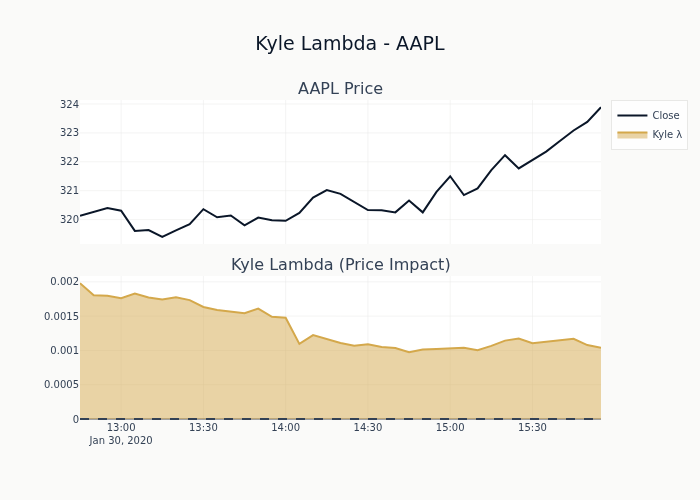

In [8]:
# Visualize Kyle Lambda
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[f"{FOCUS_STOCK} Price", "Kyle Lambda (Price Impact)"],
    vertical_spacing=0.1,
)

n = min(len(features_df), 200)  # Last ~2 days of 5m bars
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Close",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["kyle_lambda"].to_list()[-n:],
        name="Kyle λ",
        fill="tozeroy",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

fig.update_layout(height=500, title=f"Kyle Lambda - {FOCUS_STOCK}")
fig.show()

### 3.2 Amihud Illiquidity

Amihud ratio measures absolute return per dollar traded. Higher = more illiquid.

$$\text{Amihud} = \frac{1}{N} \sum_t \frac{|r_t|}{\text{DollarVolume}_t}$$

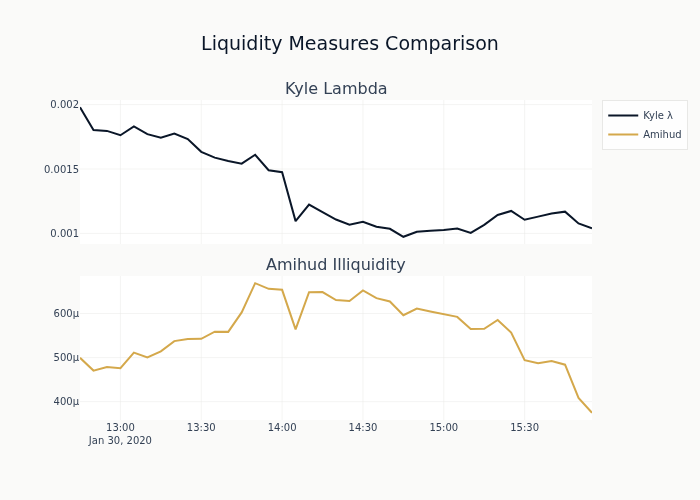

Kyle λ / Amihud correlation: -0.260


In [9]:
# Amihud vs Kyle comparison
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Kyle Lambda", "Amihud Illiquidity"],
    vertical_spacing=0.1,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["kyle_lambda"].to_list()[-n:],
        name="Kyle λ",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["amihud"].to_list()[-n:],
        name="Amihud",
    ),
    row=2,
    col=1,
)

fig.update_layout(height=500, title="Liquidity Measures Comparison")
fig.show()

# Correlation
corr = features_df.select(pl.corr("kyle_lambda", "amihud")).item()
print(f"Kyle λ / Amihud correlation: {corr:.3f}")

## 4. Order Flow Imbalance (OFI)

OFI measures the buy-sell imbalance within a bar, proxying for **net order
flow**:

$$\text{OFI} = \frac{V_{buy} - V_{sell}}{V_{buy} + V_{sell}}$$

**Important**: Without exchange-provided buy/sell labels we estimate the side
of each trade with the **tick rule** (Lee-Ready), classifying it buyer- or
seller-initiated from the sign of the price change. That classification has to
happen at the **trade** level, before aggregation - which is why
`aggregate_to_bars` splits `buy_volume`/`sell_volume` there. Applying the tick
rule to a *bar's* single close would collapse OFI to the sign of that bar's
own return (+/-1), a tautology rather than a flow measure. This is the concrete
reason OFI is a **flow** feature that needs trade data, not a bar-OHLCV
feature (Learning Objective 3).

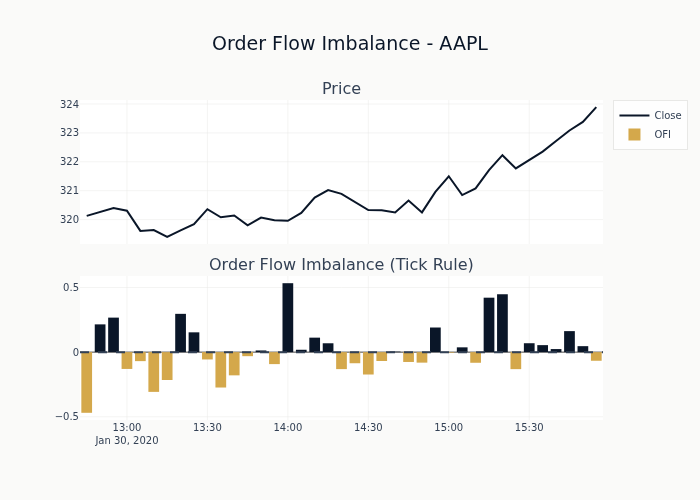

In [10]:
# OFI visualization
ofi_colors = [
    COLORS["blue"] if x > 0 else COLORS["amber"] for x in features_df["ofi"].to_list()[-n:]
]

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price", "Order Flow Imbalance (Tick Rule)"],
    vertical_spacing=0.1,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Close",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["ofi"].to_list()[-n:],
        marker_color=ofi_colors,
        name="OFI",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

fig.update_layout(height=500, title=f"Order Flow Imbalance - {FOCUS_STOCK}")
fig.show()

## 5. Feature Timing: Alpha vs Feasibility

**Critical distinction**: Some microstructure features are alpha signals;
others are feasibility/cost state variables.

| Feature | Category | Lag Requirement | Use Case |
|---------|----------|-----------------|----------|
| **OFI** | Alpha | Lagged 1+ bar | Predict next-bar returns |
| **Kyle λ** | Feasibility | Contemporaneous OK | Execution cost estimate |
| **Amihud** | Feasibility | Contemporaneous OK | Position sizing |
| **Trade Intensity** | Context | Contemporaneous OK | Regime detection |

### Alpha Features Must Be Lagged

When using OFI or similar flow features as **predictors**, you must lag them
to avoid look-ahead bias:

```python
# WRONG: using contemporaneous OFI to predict same-bar returns
df["signal"] = df["ofi"]  # Look-ahead!

# CORRECT: use lagged OFI
df["signal"] = df["ofi"].shift(1)  # Predicts next bar
```

In [11]:
# Contrast the leaky same-bar reading with the honest predictive one.
alpha_df = features_df.with_columns(
    # Next-bar return as the prediction target
    pl.col("returns").shift(-1).alias("fwd_return"),
)
alpha_df = alpha_df.drop_nulls(["ofi", "returns", "fwd_return"])

# Same-bar OFI vs same-bar return: mechanically strong because a bar with a buy
# imbalance is usually an up bar - using it as a signal peeks at the outcome.
corr_same = alpha_df.select(pl.corr("ofi", "returns")).item()
# Same OFI against the NEXT bar's return: the honest, tradable predictive content.
corr_pred = alpha_df.select(pl.corr("ofi", "fwd_return")).item()

print(f"OFI Predictive Content (n={len(alpha_df)} bars):")
print(f"  Same-bar OFI vs same-bar return:  {corr_same:+.4f} (leaky if used as a signal)")
print(f"  OFI vs next-bar return:           {corr_pred:+.4f} (honest, tradable)")

OFI Predictive Content (n=38 bars):
  Same-bar OFI vs same-bar return:  +0.5220 (leaky if used as a signal)
  OFI vs next-bar return:           +0.2133 (honest, tradable)


**Interpretation**: The contemporaneous correlation is typically much larger
than the lagged correlation - this gap is the signature of look-ahead bias.
Any strategy that uses same-bar OFI to trade same-bar returns is
implicitly assuming you know the future. The lagged correlation is the
realistic signal strength. With limited intraday data (few bars per stock),
both correlations may be noisy; longer samples sharpen the distinction.

## 6. Flow vs State: Critical Distinction

> **WARNING: Flow vs State Confusion**
>
> Many practitioners confuse **flow features** (events over a window) with
> **state features** (snapshot at a point in time).

| Concept | Example | Correct Computation |
|---------|---------|---------------------|
| **Flow** | Trades in last 5 min | Count events in window |
| **State** | Current bid-ask spread | Snapshot of book state |
| **Flow** | Volume imbalance | Sum buy vs sell volume |
| **State** | Book depth at best bid | Current LOB level |

### Order Book Spread: A State Feature

The bid-ask spread is a **state** property - the current top of book.
You cannot compute it from order **flow** (arrivals) because:

1. Cancellations remove orders but aren't in arrival flow
2. Executions remove orders from the book
3. The book has memory; flow only captures additions

**Correct approach**: Reconstruct the full LOB state (see Chapter 3).

In [12]:
# Demonstration: Flow-based "spread" is NOT the real spread
print("For LOB state reconstruction, see Chapter 3 notebooks.")
print("This notebook focuses on trade-based features (flow only).")

For LOB state reconstruction, see Chapter 3 notebooks.
This notebook focuses on trade-based features (flow only).


## 7. Composite Liquidity Score

Combining multiple liquidity metrics into a single score via z-score
normalization then summation.

### Scope: descriptive composite construction, not a prediction signal

The z-scores below use **full-sample** mean and standard deviation across the
entire history of each metric. The resulting composite is an *ex-post*
characterization of how the three illiquidity measures combine on this
sample - useful for the dashboard and the qualitative comparison that
follows. It is **not** a lookahead-safe feature: each daily z-score depends
on the global mean and variance computed over future as well as past data,
so using `illiquidity_score` directly as a regression feature would leak
future information into the training set.

The lookahead-safe construction (expanding-window percentiles / rolling
z-scores) is demonstrated in
[`06_robustness_sensitivity.py`](06_robustness_sensitivity.ipynb) §5, which
uses expanding-window quantiles to threshold a state variable without
leaking future values, and again in the per-case-study feature pipelines
under `case_studies/*/data/features/` where production features are
constructed inside walk-forward folds.

In [13]:
# Z-score normalize each feature (full-sample for illustration)
liquidity_features = ["kyle_lambda", "amihud", "roll_spread"]

for feat in liquidity_features:
    mean_val = features_df[feat].mean()
    std_val = features_df[feat].std()
    if std_val is None or std_val == 0:
        std_val = 1.0
    features_df = features_df.with_columns(
        ((pl.col(feat) - mean_val) / std_val).alias(f"{feat}_z")
    )  # Full-sample z-score - use rolling in production

# Composite illiquidity score
features_df = features_df.with_columns(
    (pl.col("kyle_lambda_z") + pl.col("amihud_z") + pl.col("roll_spread_z")).alias(
        "illiquidity_score"
    )
)

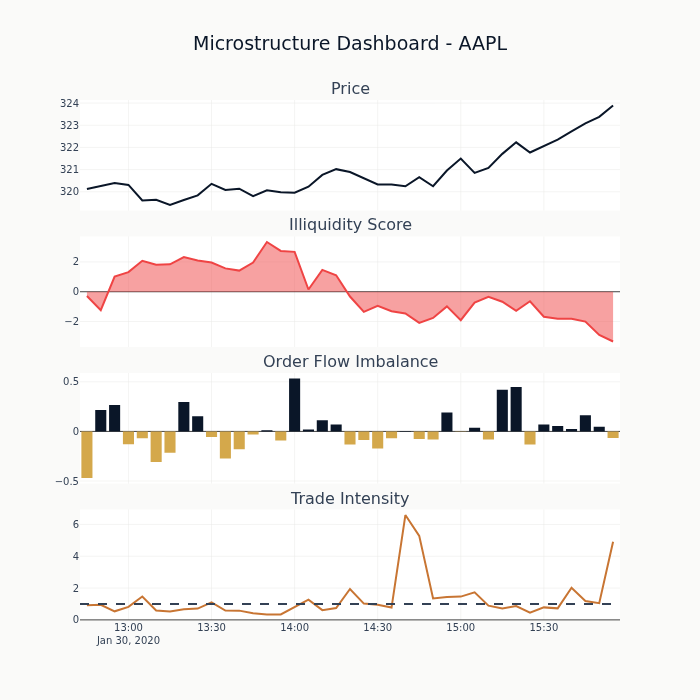

In [14]:
# Dashboard visualization
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price", "Illiquidity Score", "Order Flow Imbalance", "Trade Intensity"],
    vertical_spacing=0.05,
)

fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["close"].to_list()[-n:],
        name="Price",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["illiquidity_score"].to_list()[-n:],
        name="Illiquidity",
        fill="tozeroy",
        line=dict(color=COLORS["negative"]),
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["ofi"].to_list()[-n:],
        marker_color=ofi_colors,
        name="OFI",
    ),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=features_df["timestamp"].to_list()[-n:],
        y=features_df["trade_intensity"].to_list()[-n:],
        name="Intensity",
        line=dict(color=COLORS["copper"]),
    ),
    row=4,
    col=1,
)
fig.add_hline(y=1.0, line_dash="dash", line_color=COLORS["neutral"], row=4, col=1)

fig.update_layout(height=700, title=f"Microstructure Dashboard - {FOCUS_STOCK}", showlegend=False)
fig.show()

## 8. Cross-Stock Comparison

Microstructure features help identify which stocks are more liquid
and thus have lower trading costs.

In [15]:
# Compute features for all stocks
all_features = bars.with_columns(
    [
        kyle_lambda("returns", "volume", period=PERIOD).alias("kyle_lambda"),
        amihud_illiquidity("returns", "volume", "close", period=PERIOD).alias("amihud"),
    ]
).drop_nulls(["kyle_lambda", "amihud"])

# Summary by stock
summary = (
    all_features.group_by("stock")
    .agg(
        [
            pl.col("kyle_lambda").median().alias("kyle_median"),
            pl.col("amihud").median().alias("amihud_median"),
            pl.col("volume").sum().alias("total_volume"),
            pl.len().alias("n_bars"),
        ]
    )
    .sort("kyle_median")
)

print("Liquidity Summary by Stock:")
summary

Liquidity Summary by Stock:


stock,kyle_median,amihud_median,total_volume,n_bars
str,f64,f64,u32,u32
"""AAPL""",0.001167,0.000561,414061,40
"""MSFT""",0.001604,0.000415,1140077,58
"""TSLA""",0.003053,0.000172,1144961,58


**Interpretation**: Cross-stock liquidity differences inform **position sizing**.
Illiquid names require smaller positions to avoid market impact. Note that
Kyle lambda and Amihud can rank stocks differently - Kyle lambda captures
directional price-volume covariance while Amihud measures absolute return per
dollar traded. Using multiple liquidity proxies provides a more robust picture
than relying on any single measure. In production, these features feed the
feasibility overlay that gates position size (see `06_robustness_sensitivity`).

## Summary

### Trade-Based Features (OHLCV)

| Feature | Library Function | Use Case |
|---------|------------------|----------|
| Kyle λ | `kyle_lambda()` | Price impact estimation |
| Amihud | `amihud_illiquidity()` | Illiquidity premium |
| Roll Spread | `roll_spread_estimator()` | Transaction cost proxy |
| OFI | `effective_tick_rule()` + per-bar buy/sell aggregation | Short-term prediction |
| Trade Intensity | `trade_intensity()` | Activity regime |

### Critical Distinctions

1. **Alpha vs Feasibility**: OFI is alpha (lag it!); Kyle λ is feasibility (use directly)
2. **Flow vs State**: Trade arrivals ≠ book state; don't compute "spread" from flow
3. **Data requirements**: Kyle λ, Amihud, and Roll work on OHLCV bars; OFI is a
   flow feature that needs trade-level classification (tick rule per trade, then
   aggregate); true LOB features need book snapshots

### Integration with Strategy

- **Feasibility overlay**: Use Kyle λ, Amihud to size positions and filter illiquid names
- **Cost estimation**: Use the Roll spread estimator for transaction cost models
- **Alpha signals**: Use lagged OFI, trade intensity for short-horizon prediction

### Next Notebooks

- `03_structural_cross_instrument_features` - Cross-asset, carry, options-implied (§8.3)
- `04_fundamentals_macro_calendar` - Fundamentals, macro, calendar (§8.4)